In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ctf_dataset.load import create_wrapped_dataset
from os.path import join
from coupling_metrics import phase_synchrony, isps, cofluctuation, iscf, window_isc, window_isfc
import scipy
from itertools import combinations
import pycwt
import pandas as pd
import seaborn as sns
import sklearn

from sklearn import mixture
import statistics

from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import mutual_info_score

import json

base_dir = '/jukebox/hasson/vgraf/social-ctf'
data_dir = join(base_dir, 'data')

wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")
lstmPCs = np.load('results/lstms_tanh-z_pca-k100.npy')

datadir = "/jukebox/hasson/snastase/social-ctf/results"
lstmsNew = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 

In [3]:
spi_f = f'{datadir}/spis-fast_matchup-0.npz'
spi_npz = np.load(spi_f, allow_pickle=True)
spi_npz.files
pearsonr_spi = spi_npz['pearsonr']
pearsonr_spi.shape

(32, 32, 142, 4, 4)

In [60]:
#metrics dictionary 
clf_results = np.load(f'{datadir}/clf-pair_X-all_spi-fast_matchup-0.npy', allow_pickle=True).item()
#pcs dict of metrics dicts
pc_clf_results = np.load(f'{datadir}/clf-pair_X-pc_spi-fast_matchup-0.npy', allow_pickle=True).item()
#pc_clf_results[0]

In [61]:
with open(f'{datadir}/fav_spi_keywords.json', 'r') as f:
    fav_spis = json.load(f)
fav_spis#['anm']['keywords']
#(un)directed, (non)linear, (un)signed, bi/multivariate, contemporaneous, causal
#pairwise distance

{'anm': {'keywords': ['directed',
   'nonlinear',
   'unsigned',
   'bivariate',
   'contemporaneous',
   'causal'],
  'name': 'additive noise model'},
 'ce_gaussian': {'keywords': ['undirected',
   'nonlinear',
   'unsigned',
   'bivariate',
   'contemporaneous',
   'information'],
  'name': 'conditional entropy'},
 'cohmag_multitaper_mean_fs-1_fmin-0_fmax-0-5': {'keywords': ['undirected',
   'linear',
   'unsigned',
   'bivariate',
   'frequency-dependent',
   'spectral'],
  'name': 'coherence magnitude'},
 'coint_johansen_max_eig_stat_order-0_ardiff-1': {'keywords': ['undirected',
   'linear',
   'unsigned',
   'bivariate',
   'time-dependent',
   'miscellaneous'],
  'name': 'cointegration'},
 'cov_EmpiricalCovariance': {'keywords': ['undirected',
   'linear',
   'signed',
   'multivariate',
   'contemporaneous',
   'basic'],
  'name': 'covariance'},
 'dcoh_multitaper_mean_fs-1_fmin-0_fmax-0-5': {'keywords': ['directed',
   'linear',
   'unsigned',
   'bivariate',
   'frequency-depe

In [44]:
#directed
for metric in fav_spis:
    if fav_spis[metric]['keywords'][0]=='undirected':
        print(clf_results[metric])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


KeyError: 'pearsonr-sq'

In [56]:
for metric in fav_spis:
    if 'signed' in fav_spis[metric]['keywords']:
        print(clf_results[metric])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


In [57]:
for metric in fav_spis:
    if 'multivariate' in fav_spis[metric]['keywords']:
        print(clf_results[metric])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


In [58]:
for metric in fav_spis:
    if 'causal' in fav_spis[metric]['keywords']:
        print(clf_results[metric])

[1.     0.75   0.75   0.5625 0.875  0.9375 0.8125 0.5    0.5    0.875
 0.6875 0.625  0.5    0.75   0.625  0.6875 0.875  0.625  0.9375 0.5
 0.625  0.8125 0.875  0.6875 0.6875 0.75   1.     0.5    1.     0.4375
 0.875  0.75  ]
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [59]:
for metric in fav_spis:
    if 'pairwise distance' in fav_spis[metric]['keywords']:
        print(clf_results[metric])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


In [60]:
################################################################################################
for metric in fav_spis:
    if 'pairwise distance' in fav_spis[metric]['keywords']:
        print(pc_clf_results[0][metric])

[0.375 0.375 0.75  0.625 0.625 0.75  0.5   0.5   0.875 0.75  0.625 0.25
 0.5   0.5   0.625 0.75  0.25  0.625 0.625 0.375 0.375 0.25  0.5   0.875
 0.625 0.75  0.5   0.125 0.5   0.625 0.75  0.5  ]
[0.375 0.5   0.75  0.625 0.375 0.75  0.5   0.5   0.875 0.75  0.625 0.25
 0.5   0.5   0.75  0.75  0.25  0.625 0.625 0.375 0.375 0.25  0.5   0.875
 0.625 0.75  0.5   0.125 0.5   0.625 0.75  0.5  ]


In [61]:
for metric in fav_spis:
    if 'multivariate' in fav_spis[metric]['keywords']:
        print(pc_clf_results[0][metric])

[0.375 0.375 0.75  0.625 0.625 0.75  0.5   0.5   0.875 0.75  0.625 0.25
 0.5   0.5   0.625 0.75  0.25  0.625 0.625 0.375 0.375 0.25  0.5   0.875
 0.625 0.75  0.5   0.125 0.5   0.625 0.75  0.5  ]
[0.625 0.375 0.25  0.875 0.625 0.5   0.625 0.75  0.875 0.75  0.5   0.375
 0.375 0.5   0.625 0.625 0.75  0.875 0.625 0.625 0.625 0.375 0.25  0.75
 0.25  0.375 0.375 0.625 0.5   0.625 0.5   0.75 ]


In [62]:
for metric in fav_spis:
    if 'multivariate' in fav_spis[metric]['keywords']:
        print(pc_clf_results[1][metric])

[0.5   1.    0.625 0.625 0.75  0.75  1.    0.875 0.875 0.75  0.875 0.625
 0.875 0.625 0.875 0.5   0.625 0.5   0.75  0.375 0.5   0.75  0.5   0.75
 0.375 0.875 0.875 0.75  0.625 0.625 0.625 0.5  ]
[0.75  0.75  0.5   0.625 0.75  1.    1.    0.875 0.875 0.875 0.875 0.5
 0.875 0.625 0.875 0.5   0.875 0.75  0.625 0.625 0.875 1.    1.    0.75
 0.5   0.875 0.75  0.625 0.75  0.875 0.625 0.5  ]


In [18]:
'''means = np.empty(shape=(8,0))
labels=[]
for pc in range(10):
    temp = []
    for metric in fav_spis:
        if 'directed' in fav_spis[metric]['keywords']:
            labels.append(metric)
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
    means = np.concatenate((means, np.array(temp)[:,np.newaxis]), axis=1)
means'''

array([[0.66992188, 0.4765625 , 0.60351562, 0.50195312, 0.6953125 ,
        0.53710938, 0.58789062, 0.48242188, 0.50195312, 0.76953125],
       [0.37109375, 0.5546875 , 0.61132812, 0.51757812, 0.80273438,
        0.51367188, 0.50976562, 0.5234375 , 0.60546875, 0.7265625 ],
       [0.51953125, 0.50976562, 0.53320312, 0.50390625, 0.57421875,
        0.51367188, 0.5703125 , 0.50976562, 0.49804688, 0.50195312],
       [0.53125   , 0.58398438, 0.75      , 0.56640625, 0.7578125 ,
        0.47851562, 0.51757812, 0.515625  , 0.57617188, 0.6796875 ],
       [0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ],
       [0.5390625 , 0.55859375, 0.60546875, 0.63671875, 0.59765625,
        0.36328125, 0.5390625 , 0.7421875 , 0.6015625 , 0.80078125],
       [0.515625  , 0.55859375, 0.54882812, 0.46679688, 0.6640625 ,
        0.515625  , 0.55664062, 0.578125  , 0.53320312, 0.53515625],
       [0.5       , 0.53710938, 0.6054687

In [25]:
means = np.empty(shape=(0,10))
labels=[]
for metric in fav_spis:
    if 'directed' in fav_spis[metric]['keywords']:
        temp = []
        labels.append(metric)
        for pc in range(10):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        #print(means.shape, temp.shape)
        means = np.concatenate((means, temp), axis=0)
means

array([[0.66992188, 0.4765625 , 0.60351562, 0.50195312, 0.6953125 ,
        0.53710938, 0.58789062, 0.48242188, 0.50195312, 0.76953125],
       [0.37109375, 0.5546875 , 0.61132812, 0.51757812, 0.80273438,
        0.51367188, 0.50976562, 0.5234375 , 0.60546875, 0.7265625 ],
       [0.51953125, 0.50976562, 0.53320312, 0.50390625, 0.57421875,
        0.51367188, 0.5703125 , 0.50976562, 0.49804688, 0.50195312],
       [0.53125   , 0.58398438, 0.75      , 0.56640625, 0.7578125 ,
        0.47851562, 0.51757812, 0.515625  , 0.57617188, 0.6796875 ],
       [0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ],
       [0.5390625 , 0.55859375, 0.60546875, 0.63671875, 0.59765625,
        0.36328125, 0.5390625 , 0.7421875 , 0.6015625 , 0.80078125],
       [0.515625  , 0.55859375, 0.54882812, 0.46679688, 0.6640625 ,
        0.515625  , 0.55664062, 0.578125  , 0.53320312, 0.53515625],
       [0.5       , 0.53710938, 0.6054687

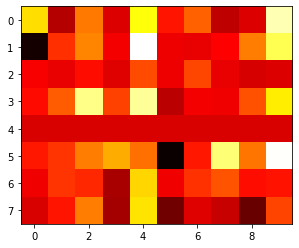

In [23]:
plt.imshow(means, cmap='hot', interpolation='nearest')
plt.show()

In [26]:
means.shape
len(labels)

8

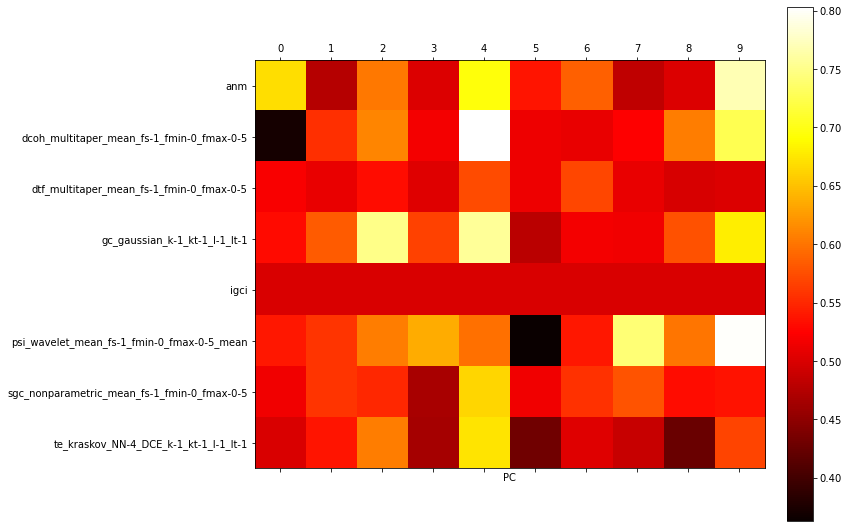

In [42]:
fig,ax = plt.subplots(figsize=(10,10))
n=ax.matshow(means, cmap='hot') 
fig.colorbar(n,fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(10))
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels);

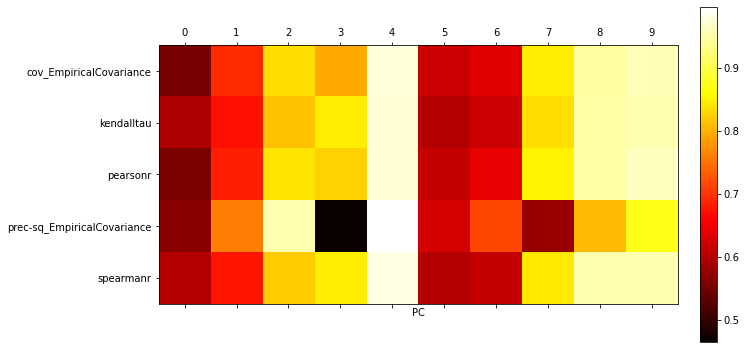

In [48]:
meansSigned = np.empty(shape=(0,10))
labelsSigned=[]
for metric in fav_spis:
    if 'signed' in fav_spis[metric]['keywords']:
        temp = []
        labelsSigned.append(metric)
        for pc in range(10):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        #print(means.shape, temp.shape)
        meansSigned = np.concatenate((meansSigned, temp), axis=0)
fig,ax = plt.subplots(figsize=(10,10))
n=ax.matshow(meansSigned, cmap='hot') 
fig.colorbar(n,fraction=0.03, pad=0.04)
ax.set_xticks(np.arange(10))
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labelsSigned)))
ax.set_yticklabels(labelsSigned);

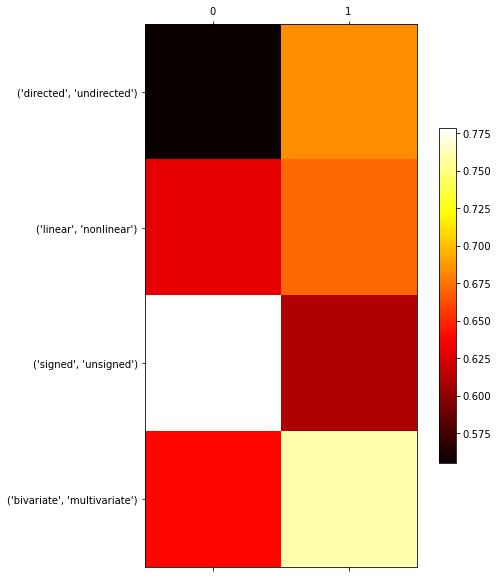

In [59]:
#(un)directed, (non)linear, (un)signed, bi/multivariate, contemporaneous, causal
keywords = [('directed', 'undirected'), ('linear', 'nonlinear'), ('signed', 'unsigned'), ('bivariate', 'multivariate')] 
means = np.empty(shape=(0,2))
labels=[]
for key in keywords:
    temp1 = []
    temp2 = []
    for pc in range(10):
        for metric in fav_spis:
            if metric=='pearsonr-sq':
                metric = 'pearsonr'
            if key[0] in fav_spis[metric]['keywords']:
                #labels.append(metric)
                temp1.append(np.mean(np.array(pc_clf_results[pc][metric])))
            elif key[1] in fav_spis[metric]['keywords']:
                #labels.append(metric)
                temp2.append(np.mean(np.array(pc_clf_results[pc][metric])))
    temp=np.array([np.mean(temp1),np.mean(temp2)])[np.newaxis,:]
    #print(means.shape, temp.shape)
    means = np.concatenate((means, temp), axis=0)
fig,ax = plt.subplots(figsize=(10,10))
n=ax.matshow(means, cmap='hot') 
fig.colorbar(n,fraction=0.03, pad=0.04)
#ax.set_xticks(np.arange(10))
#ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(keywords)))
ax.set_yticklabels(keywords);

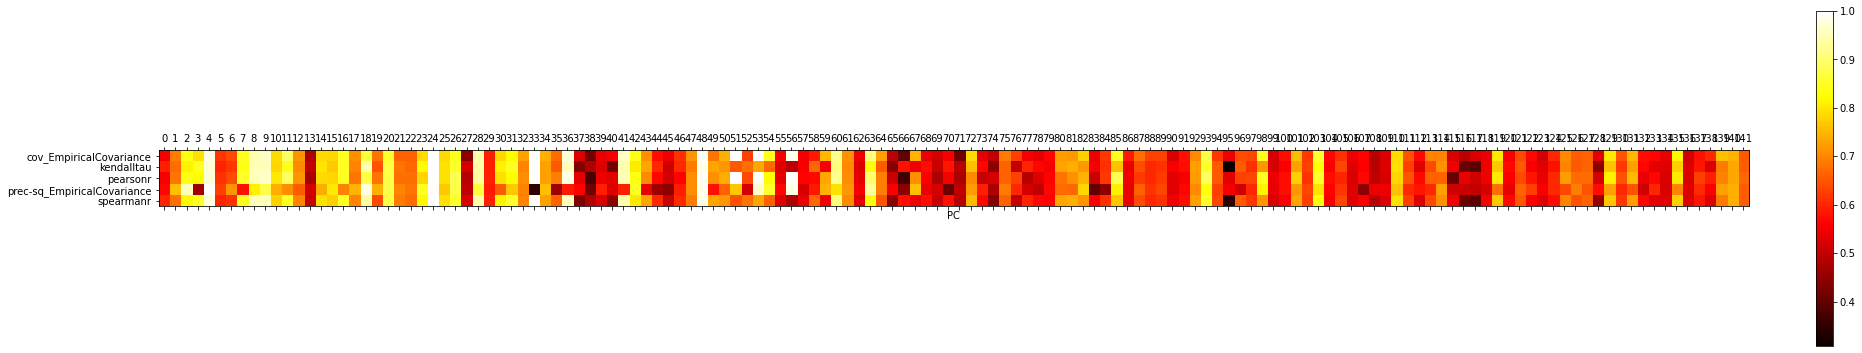

In [66]:
numPCs = 142
meansSigned = np.empty(shape=(0,numPCs))
labelsSigned=[]
for metric in fav_spis:
    if 'signed' in fav_spis[metric]['keywords']:
        temp = []
        labelsSigned.append(metric)
        for pc in range(numPCs):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        #print(means.shape, temp.shape)
        meansSigned = np.concatenate((meansSigned, temp), axis=0)
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(meansSigned, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(numPCs))
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labelsSigned)))
ax.set_yticklabels(labelsSigned);

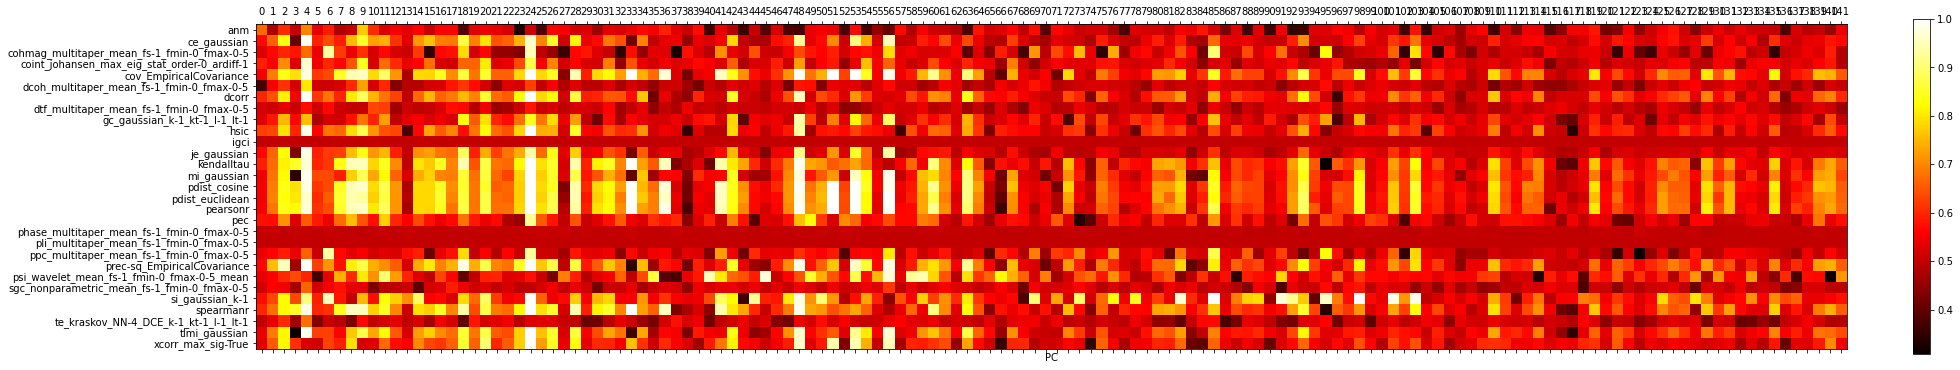

In [83]:
numPCs = 142
meansSigned = np.empty(shape=(0,numPCs))
labelsSigned=[]
for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    #if 'nonlinear' in fav_spis[metric]['keywords']:
    temp = []
    labelsSigned.append(metric)
    for pc in range(numPCs):
        temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
    temp=np.array(temp)[np.newaxis,:]
    #print(means.shape, temp.shape)
    meansSigned = np.concatenate((meansSigned, temp), axis=0)
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(meansSigned, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(numPCs))
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labelsSigned)))
ax.set_yticklabels(labelsSigned);

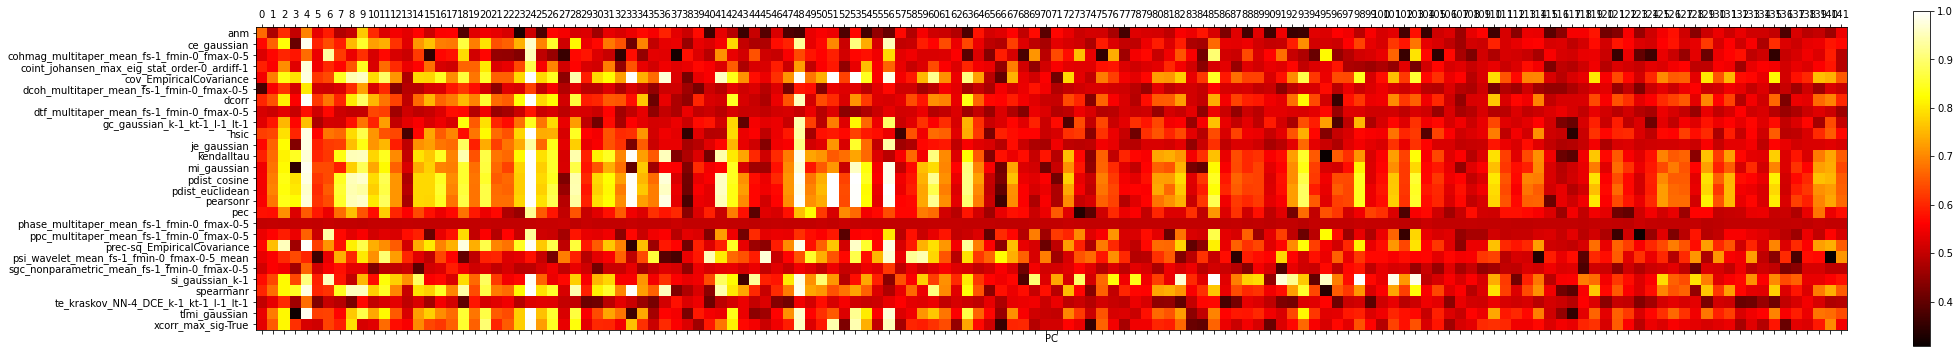

In [84]:
numPCs = 142
meansSigned = np.empty(shape=(0,numPCs))
labelsSigned=[]
for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    #if 'nonlinear' in fav_spis[metric]['keywords']:
    if np.mean(np.array(pc_clf_results[1][metric]))==0.5:
        continue
    temp = []
    labelsSigned.append(metric)
    for pc in range(numPCs):
        temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
    temp=np.array(temp)[np.newaxis,:]
    #print(means.shape, temp.shape)
    meansSigned = np.concatenate((meansSigned, temp), axis=0)
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(meansSigned, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(numPCs))
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labelsSigned)))
ax.set_yticklabels(labelsSigned);

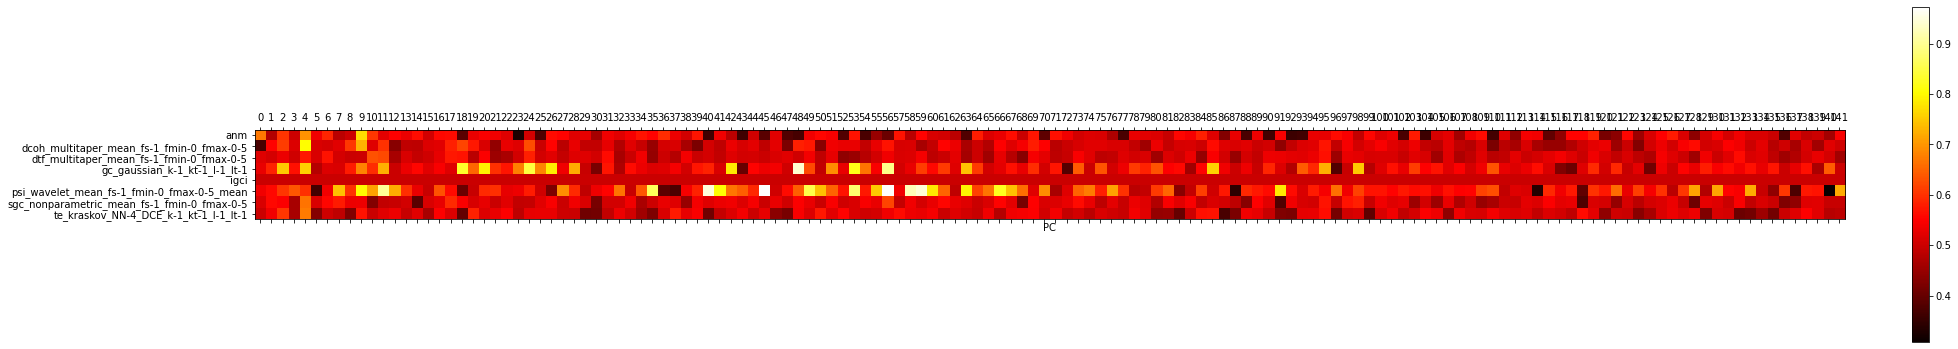

In [86]:
numPCs = 142
meansSigned = np.empty(shape=(0,numPCs))
labelsSigned=[]
for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    if 'directed' in fav_spis[metric]['keywords']:
        temp = []
        labelsSigned.append(metric)
        for pc in range(numPCs):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        #print(means.shape, temp.shape)
        meansSigned = np.concatenate((meansSigned, temp), axis=0)
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(meansSigned, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(numPCs))
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labelsSigned)))
ax.set_yticklabels(labelsSigned);

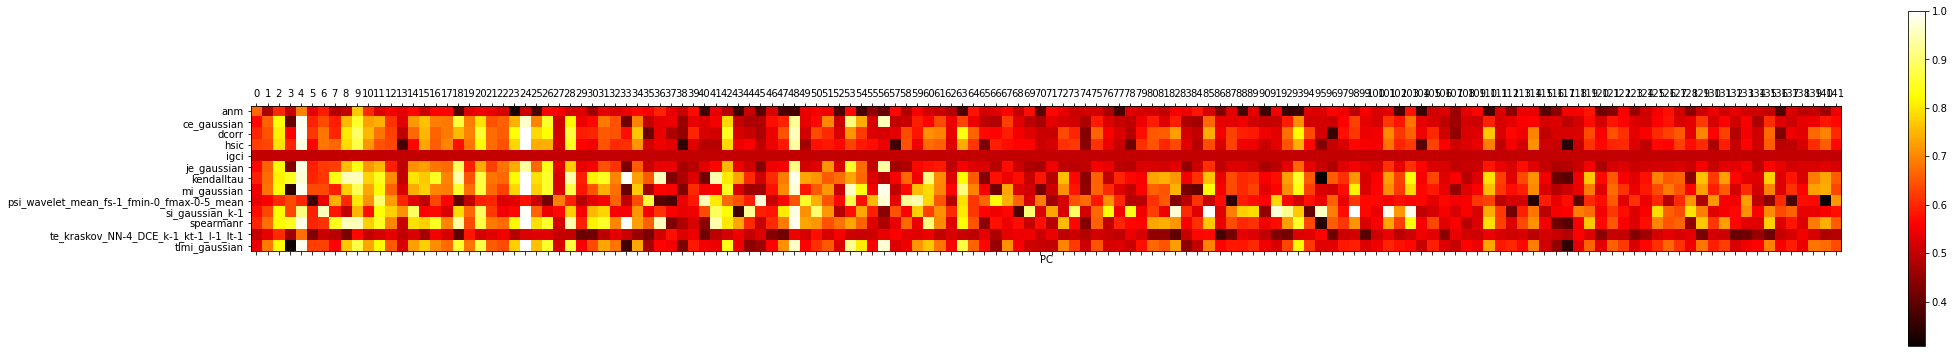

In [87]:
numPCs = 142
meansSigned = np.empty(shape=(0,numPCs))
labelsSigned=[]
for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    if 'nonlinear' in fav_spis[metric]['keywords']:
        temp = []
        labelsSigned.append(metric)
        for pc in range(numPCs):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        #print(means.shape, temp.shape)
        meansSigned = np.concatenate((meansSigned, temp), axis=0)
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(meansSigned, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(numPCs))
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labelsSigned)))
ax.set_yticklabels(labelsSigned);

In [ ]:
#anm, cohmag_multitaper_mean, dcoh_multitaper_mean, dtf_, pec, phase_, pcc_, psi_wavelet_mean, 
#sgc_nonparametric_mean, te_traskov